In [131]:
import sys
sys.path.insert(0, '..')

In [132]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)

# Optimisation imports
import zodiax as zdx
import optax

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *


def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

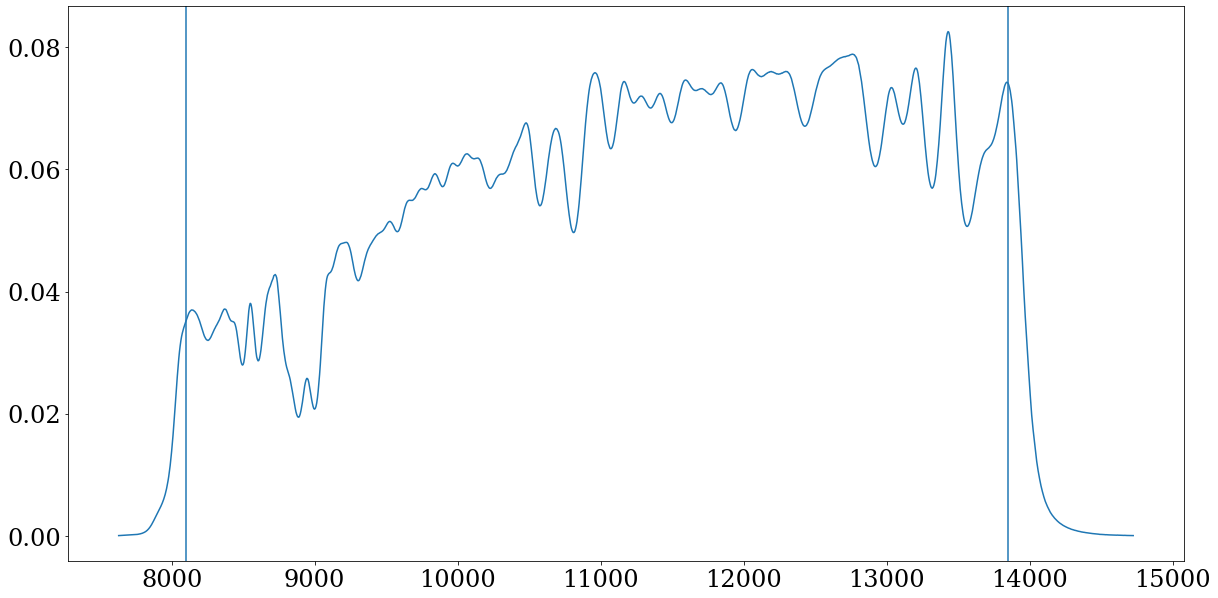

In [133]:
plt.figure(figsize=(20,10))
flt = get_filter("../data/HST_NICMOS1.F110W.dat")
plt.plot(flt[:,0], flt[:,1])
plt.axvline(8100)
plt.axvline(13850)

In [134]:
wid = 72
oversample = 4

filt = "F110W"

nwavels = 1420//4
npoly=nwavels
n_zernikes = 20

optics = NICMOSFresnelOptics(512, wid, oversample, n_zernikes = n_zernikes, defocus=0., fnumber=80.)
detector = NICMOSDetector(oversample, wid)

In [135]:
wavels, bandpass = calc_throughput("F110W", nwavels=nwavels)

In [136]:
wavels, weights = calc_throughput(filt, nwavels)


In [137]:
data = np.load("spectrum_iterative.npz", allow_pickle=True)
weights = np.ones_like(data["weights"])
#weights = (data["weights"])

params = data["params"][()]

key_name = list(params["aberrations"].keys())[0]

In [138]:
weights.shape

(20,)

In [139]:
basis_weights = np.ones(nwavels)+8#weights #+ 7
#basis_weights = weights #+ 7

In [140]:
spectrum_basis = np.eye(nwavels)
#spectrum_basis = np.load("spectrum_basis.npy")[:,:npoly]

In [141]:
exposures = [
    BlankExposure(key_name, filt, SinglePointFit(spectrum_basis, filt))
] 


/var/folders/hv/659ls99s2sjd7m3dfr17k8cm0000gn/T/ipykernel_49536/3507026079.py:2: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  BlankExposure(key_name, filt, SinglePointFit(spectrum_basis, filt))


In [142]:
params

{'aberrations': {'n9nk29c8q': Array([ 15.70485847,  -6.42601495,  -6.89652127,   0.18626012,
          -2.96659289,  -4.48225275,  11.34732398,  -1.03732437,
          -1.06578719,  -2.98699951,   0.84542589,  12.24000996,
         -10.9147922 ,  -3.19445695,  -0.31283715,  -0.57784523,
          -0.37907498,  -0.32314311,  -5.65932405,   0.83296164],      dtype=float64),
  'n9nk29d1q': Array([ 10.43237483,  -4.29778022, -13.07292628,   2.78027988,
          -1.38348432, -10.28813355,  14.11730828,  -0.50629475,
          -1.01348697,  -2.115823  ,  -1.70582991,  11.72629805,
          -7.3639778 ,  -0.12215625,   0.62716545,  -4.2222633 ,
          -2.17367664,  -2.3950267 ,  -6.15599728,  -0.6261574 ],      dtype=float64)},
 'bias': {'n9nk29c8q': Array(0.03398191, dtype=float64),
  'n9nk29d1q': Array(0.02905284, dtype=float64)},
 'cold_mask_shear': {'global': Array([-0.1515148 , -0.21916038], dtype=float64)},
 'cold_mask_shift': {'global': Array([6.59696401, 5.99473592], dtype=float6

In [143]:
base_params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 20.,#0.1,
    "bias": {},
    "jitter": {},

    "defocus": {},#1e5#{}
    "fnumber": 80.,
    "quadrature": {},
}



for idx, exp in enumerate(exposures):
    base_params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    base_params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set(np.log10(np.nansum(exp.data)/nwavels))
    base_params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)
    base_params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([6.,6.])
    base_params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    base_params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    base_params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    base_params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    base_params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    base_params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    base_params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.
    
    base_params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    base_params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample
    base_params["quadrature"][exp.fit.get_key(exp, "quadrature")] = 0.

params = base_params | params | {"spectrum": {f"{key_name}_F110W": basis_weights}}

injected_model = set_array(NICMOSModel(exposures, params, optics, detector))

injected_params = ModelParams(params)

In [144]:
injected_params

ModelParams(
  params={
    'positions': {'n9nk29c8q': f64[2], 'n9nk29d1q': f64[2]},
    'spectrum': {'n9nk29c8q_F110W': f64[355]},
    'aberrations': {'n9nk29c8q': f64[20], 'n9nk29d1q': f64[20]},
    'cold_mask_shift': {'global': f64[2]},
    'cold_mask_rot': {'global': -45.0},
    'cold_mask_scale': {'global': f64[2]},
    'cold_mask_shear': {'global': f64[2]},
    'primary_scale': {'global': f64[2]},
    'primary_rot': {'global': 45.0},
    'primary_shear': {'global': f64[2]},
    'outer_radius': 1.146,
    'secondary_radius': 0.44639999999999996,
    'spider_width': 0.0924,
    'softening': 20.0,
    'bias': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'jitter': {'n9nk29c8q': 0.6511627906976745},
    'defocus': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'fnumber': 80.0,
    'quadrature': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]}
  }
)

In [145]:
exposures = [
    #InjectedExposure("test", 'F110W', SinglePointSpectrumFit(nwavels), injected_model, 287*1e-3, 10)
    InjectedExposure(key_name, filt, SinglePointFit(spectrum_basis, filt), injected_model, 100, 1, read_noise=0.)
]

/var/folders/hv/659ls99s2sjd7m3dfr17k8cm0000gn/T/ipykernel_49536/3807808512.py:3: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  InjectedExposure(key_name, filt, SinglePointFit(spectrum_basis, filt), injected_model, 100, 1, read_noise=0.)


In [146]:
# exposures = [
#     LoadedExposure(key_name, filt, SinglePointFit(np.eye(nwavels), filt, precombined=True, wavels=wavels), exp.data, exp.err, exp.bad) for exp in exposures
# ]

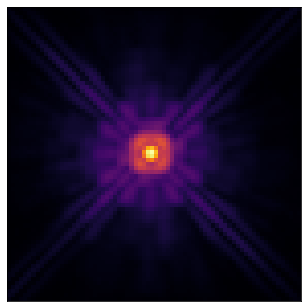

In [147]:
plt.imshow(exposures[0].data**0.125)
plt.xticks([])
plt.yticks([])
plt.tight_layout()

In [148]:
print(np.sum(exposures[0].data))

3237.999389602242


In [149]:
11811045.472931193/18717.32145868043

631.0222057683178

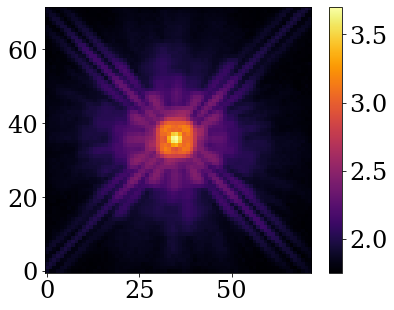

In [150]:
plt.imshow(np.log10(exposures[0].data/exposures[0].err))
plt.colorbar()

In [151]:


model = set_array(NICMOSModel(exposures, injected_params.params, optics, detector))

old_params = params
params = injected_params#ModelParams(injected_params)

In [152]:
old_params

{'positions': {'n9nk29c8q': Array([ 0.95822182, -0.06188152], dtype=float64),
  'n9nk29d1q': Array([-0.43070137,  0.6730589 ], dtype=float64)},
 'spectrum': {'n9nk29c8q_F110W': Array([9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9.,
         9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9.,
         9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9.,
         9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9.,
         9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9.,
         9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9.,
         9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9.,
         9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9.,
         9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9.,
         9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9.,
         9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9., 9.

In [153]:
model

NICMOSModel(
  params={
    'aberrations': {'n9nk29c8q': f64[20], 'n9nk29d1q': f64[20]},
    'bias': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'cold_mask_rot': {'global': f64[]},
    'cold_mask_scale': {'global': f64[2]},
    'cold_mask_shear': {'global': f64[2]},
    'cold_mask_shift': {'global': f64[2]},
    'defocus': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'fnumber': f64[],
    'jitter': {'n9nk29c8q': f64[]},
    'outer_radius': f64[],
    'positions': {'n9nk29c8q': f64[2], 'n9nk29d1q': f64[2]},
    'primary_rot': {'global': f64[]},
    'primary_scale': {'global': f64[2]},
    'primary_shear': {'global': f64[2]},
    'quadrature': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'secondary_radius': f64[],
    'softening': f64[],
    'spectrum': {'n9nk29c8q_F110W': f64[355]},
    'spider_width': f64[]
  },
  filters={'F110W': f64[284,2]},
  optics=NICMOSFresnelOptics(
    wf_npixels=512,
    diameter=f64[],
    layers={
      'CompoundAperture':
      CompoundAperture(
      

In [154]:
model_forecast = injected_params.inject(model)

In [155]:
def loss_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures]))

spec_params = ModelParams({"spectrum": injected_params.get("spectrum")})

f = lambda params: loss_fn(ModelParams(injected_params.params | params.params), exposures, params.inject((model)))
F, unflatten = zdx.batching.hessian(f, spec_params, nbatches=20*len(exposures))

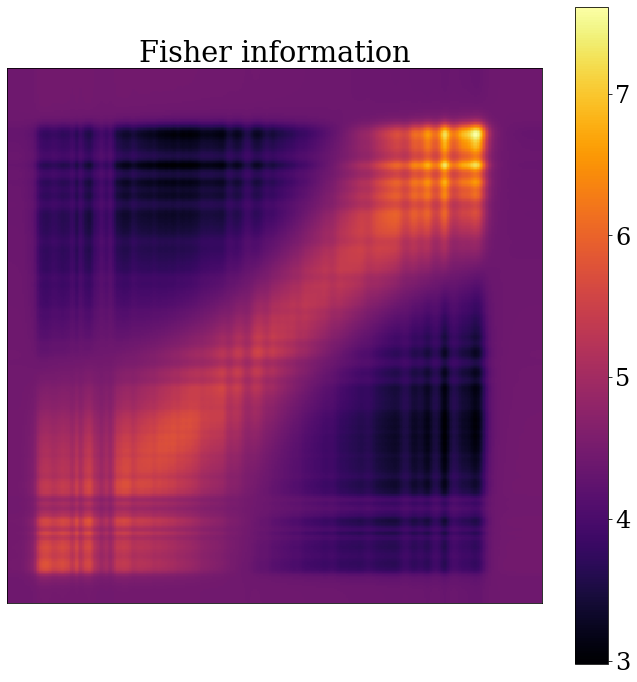

In [156]:
plt.figure(figsize=(10,10))
plt.imshow(F, interpolation='none')
plt.title("Fisher information")
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.tight_layout()

In [157]:
np.sum(np.abs(F - F.T)**2)

Array(4.05757036e-24, dtype=float64)

In [158]:
np.min(F)

Array(2.97931389, dtype=float64)

In [159]:
np.linalg.inv(F)

Array([[ 2.03054157e+13,  9.43914159e+13, -1.53895362e+14, ...,
         2.75254329e+14, -1.74215912e+14, -2.16371174e+14],
       [ 1.47228883e+13, -7.54373350e+13,  6.33263719e+13, ...,
        -1.60510230e+14,  1.59279266e+13,  1.56667416e+14],
       [-8.11406917e+13, -1.50538353e+13,  1.98078216e+14, ...,
        -2.59529353e+14,  3.32004908e+14,  6.57523789e+13],
       ...,
       [-1.04988286e+14,  4.11405007e+13,  1.62547611e+14, ...,
        -1.66487745e+14,  2.68026384e+14,  6.69177614e+12],
       [-8.31581604e+13,  1.19954626e+14, -2.13791346e+13, ...,
         5.09698516e+13,  2.50194666e+14, -2.09661069e+14],
       [ 7.59649513e+13, -3.54194127e+13, -1.24305565e+14, ...,
         1.95522097e+14, -3.02821128e+14,  1.23304087e+14]],      dtype=float64)

In [160]:
np.real(np.linalg.eig(F)[0].sort()[::-1])

Array([ 1.56686067e+03,  2.04160269e+02,  7.71956316e+01,  2.82919273e+01,
        1.76103222e+01,  9.54540314e+00,  4.85562281e+00,  3.27823833e+00,
        2.04110026e+00,  1.14976434e+00,  8.64559256e-01,  5.59794800e-01,
        2.79939021e-01,  2.01999184e-01,  1.60554881e-01,  8.69441805e-02,
        4.87999168e-02,  3.55608266e-02,  2.05656988e-02,  1.15006877e-02,
        7.26457906e-03,  4.37414194e-03,  2.40311344e-03,  1.23143239e-03,
        6.68014069e-04,  3.06243193e-04,  1.42177888e-04,  6.24340914e-05,
        2.20967555e-05,  8.71865588e-06,  1.83053062e-06,  9.41692120e-07,
        1.33639128e-07,  5.81972964e-08,  9.74587437e-09,  2.01708843e-09,
        5.09555257e-10,  4.37547166e-11,  1.12356286e-11,  7.19638424e-13,
        1.18664312e-13,  6.93843349e-14,  6.93843349e-14,  6.83690243e-14,
        6.83690243e-14,  6.83509726e-14,  6.83509726e-14,  6.35903677e-14,
        6.35903677e-14,  6.09791474e-14,  6.09791474e-14,  6.00840867e-14,
        6.00840867e-14,  

Text(0, 0.5, 'Eigenvalue')

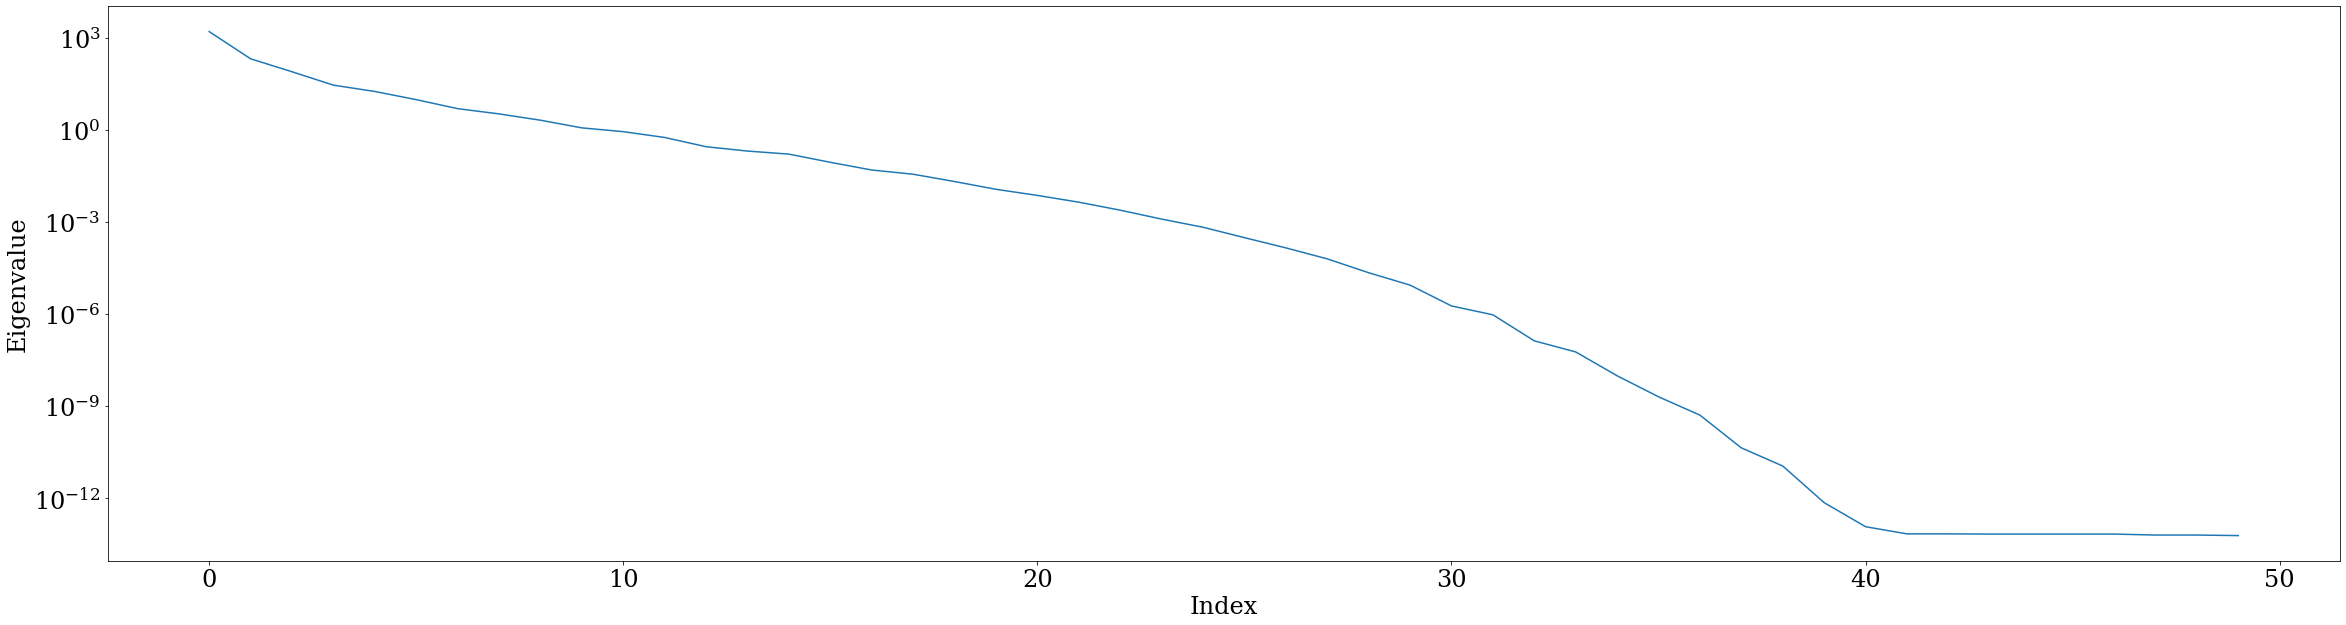

In [161]:
plt.figure(figsize=(40,10))
plt.semilogy(np.real(np.linalg.eig(F)[0].sort()[::-1])[:50])
plt.xlabel("Index")
plt.ylabel("Eigenvalue")

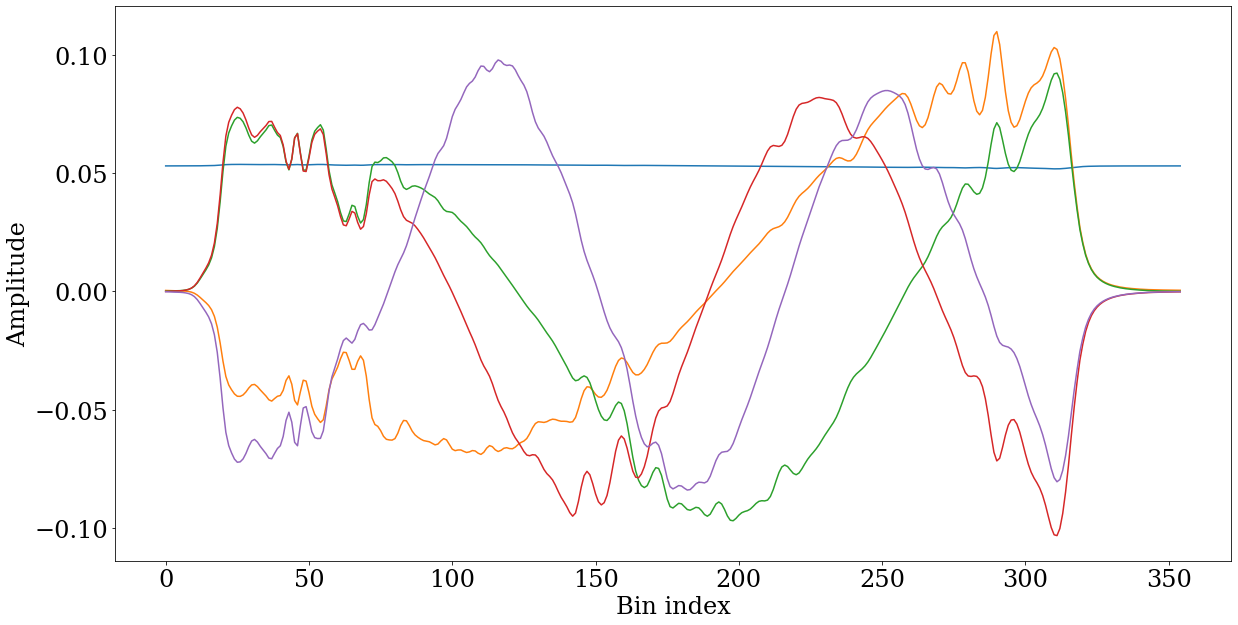

In [162]:
vals, vects = np.linalg.eig(F)

order = np.argsort(vals)[::-1]

plt.figure(figsize=(20,10))
plt.xlabel("Bin index")
plt.ylabel("Amplitude")

for i in range(5):
    plt.plot(np.real(vects[:,order[i]]))

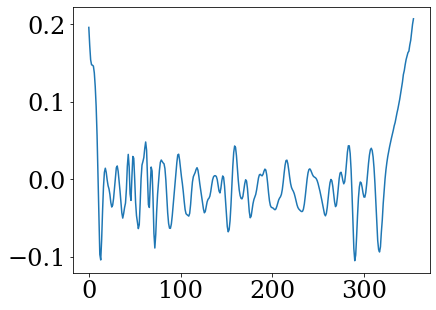

In [163]:
plt.plot(np.real(vects[:,order[-1]]))

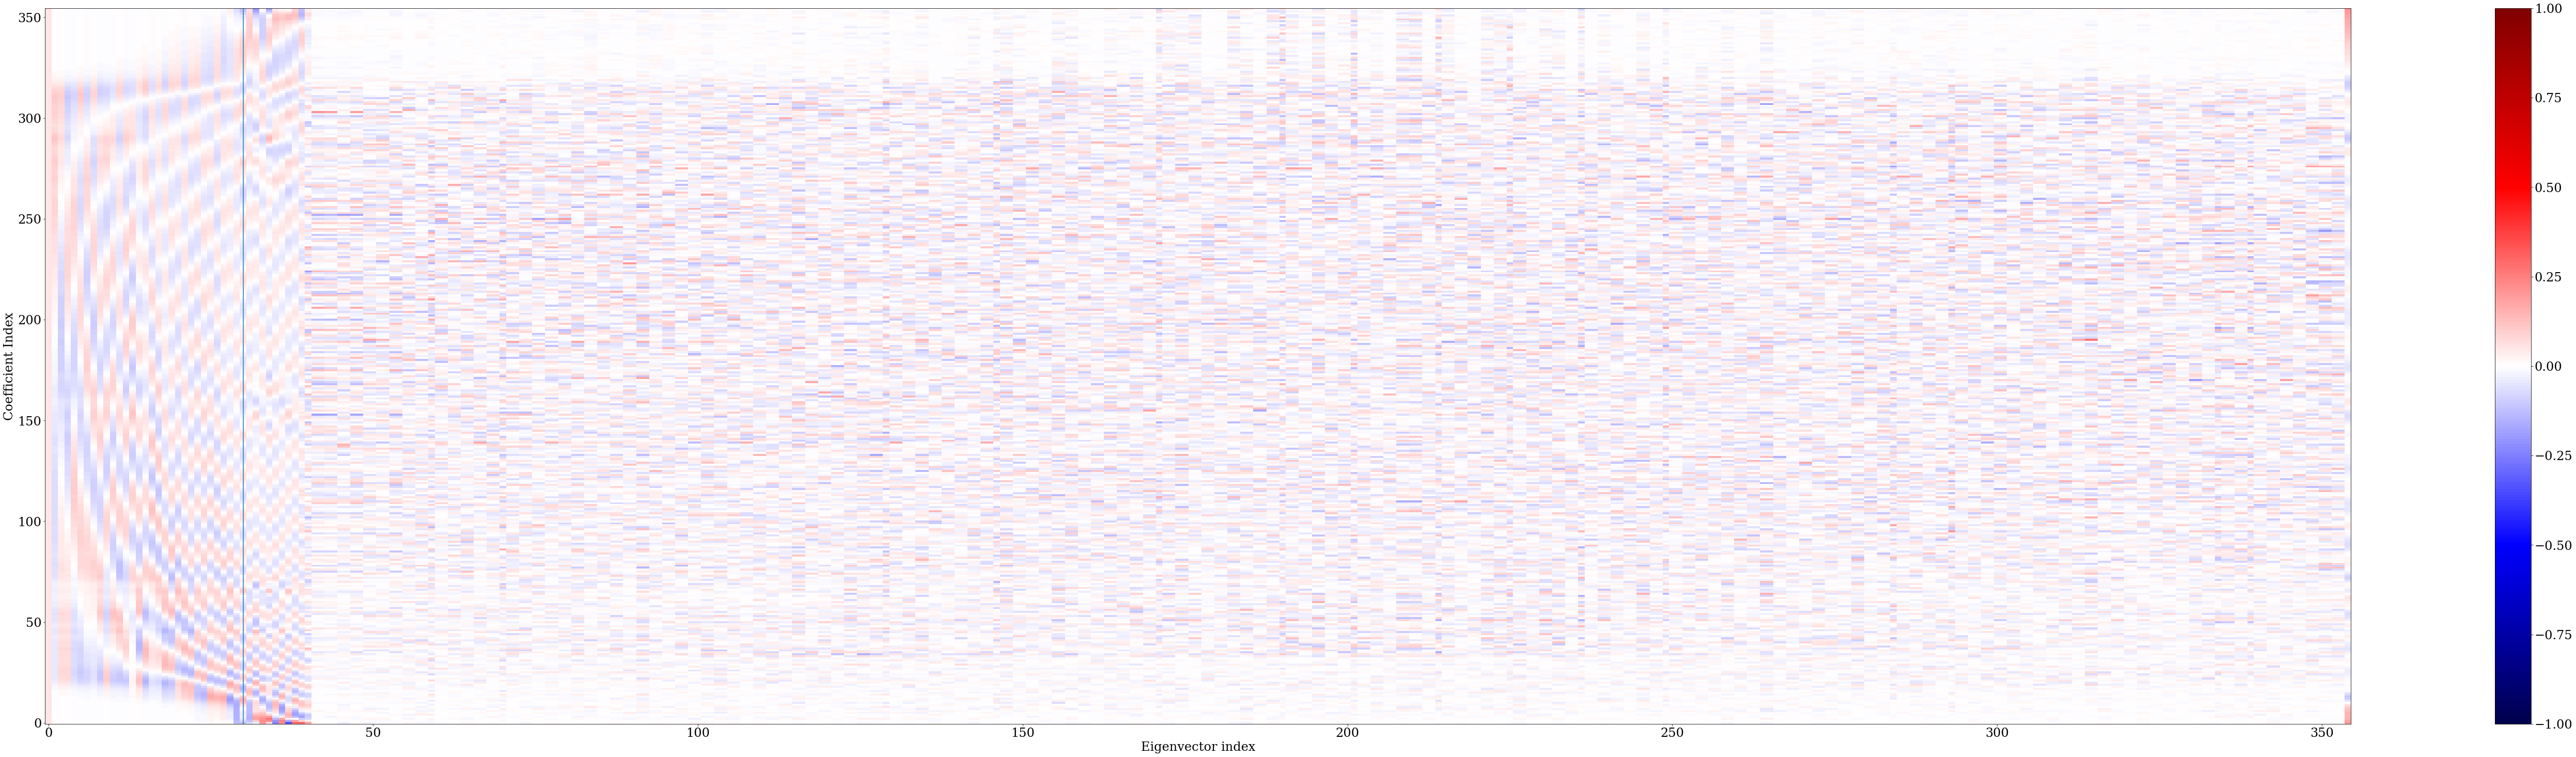

In [164]:
plt.figure(figsize=(20*5,5*5))
plt.imshow(np.real(vects[:,order[:]]), cmap='seismic', vmax=1, vmin=-1, interpolation='none', aspect='auto')
plt.xlabel("Eigenvector index")
plt.ylabel("Coefficient Index")
plt.colorbar()
plt.axvline(30)

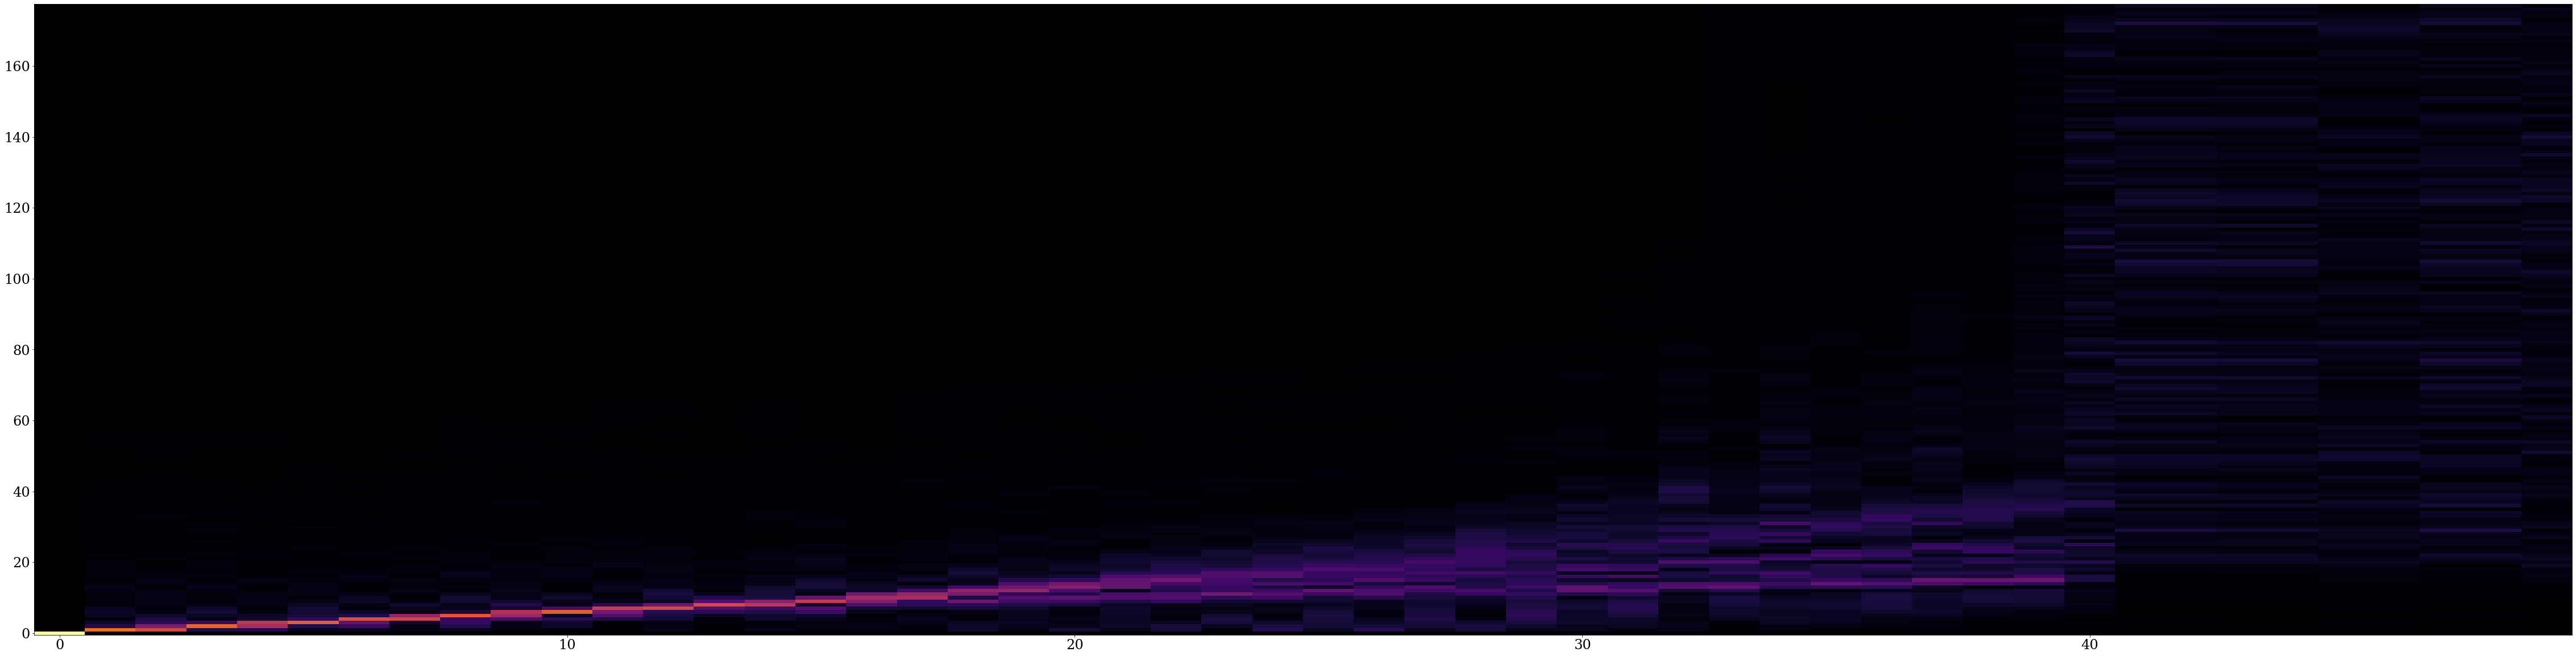

In [165]:
plt.figure(figsize=(20*4, 5*4))
modal_spectrum = np.abs(np.fft.rfft(np.real(vects[:,order[:50]]), axis=0))
plt.imshow(modal_spectrum, aspect='auto')

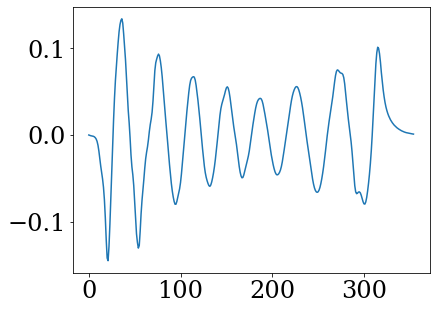

In [166]:
plt.plot(np.real(vects[:,order[15]]))

In [167]:
vcts = np.real(vects[:,order])
vects_adj = vcts#*np.ones(nwavels).at[0].mul(-1)
numpy.save(f"../data/iterative_spectrum_basis.npy", np.real(vects_adj))

In [168]:
wavels, bandpass = calc_throughput("F110W", nwavels=nwavels)

In [169]:
bandpass.shape

(355,)

In [170]:
wv, filt = calc_throughput(filt, nwavels=nwavels)


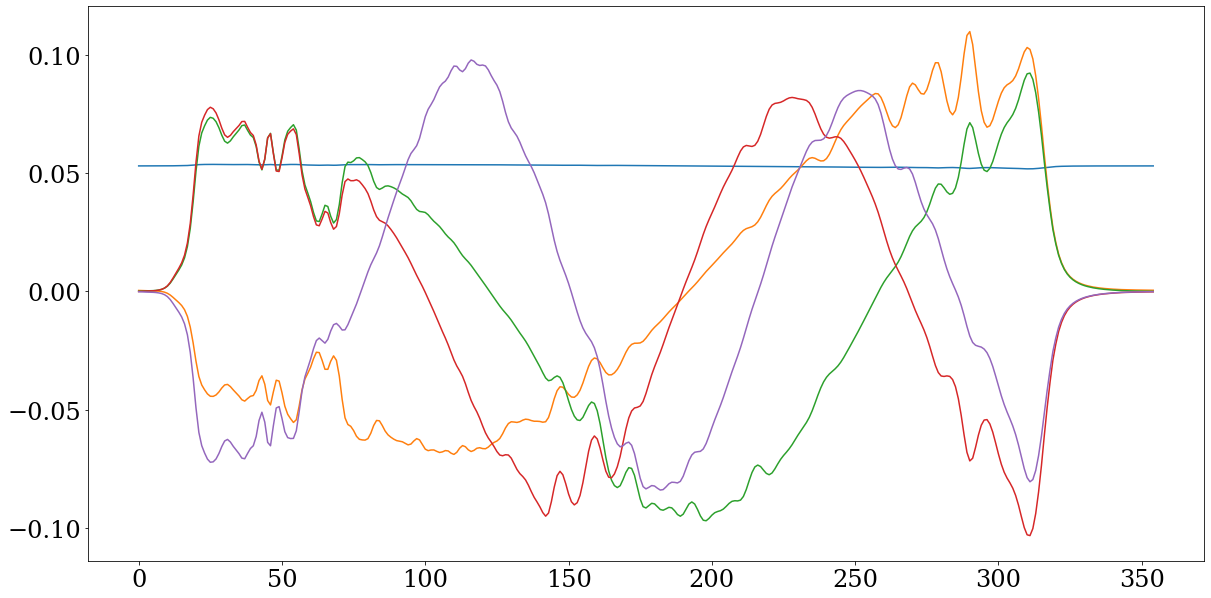

In [171]:
plt.figure(figsize=(20,10))



for i in range(5):
    plt.plot(np.real(vects_adj[:,i]*1))

In [172]:
nvects = npoly
nwavels_binned = 20
upsample = 2

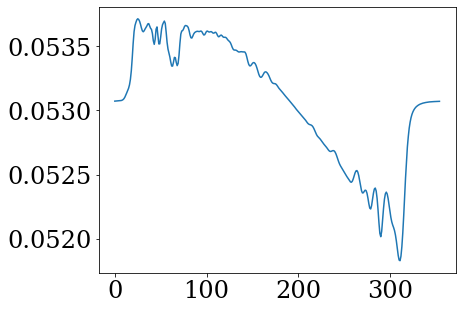

In [173]:
plt.plot(vects_adj[:,0])

In [185]:
bandpass/np.max(bandpass)

Array([5.20957118e-04, 9.09437626e-04, 1.29741686e-03, 1.55928882e-03,
       1.76891083e-03, 2.05054106e-03, 2.61333354e-03, 3.63642195e-03,
       5.32682203e-03, 8.24859521e-03, 1.32689389e-02, 2.11425021e-02,
       3.16734672e-02, 4.31431997e-02, 5.44437258e-02, 6.73051603e-02,
       8.55103708e-02, 1.14445812e-01, 1.60974575e-01, 2.28826598e-01,
       3.07829167e-01, 3.72071665e-01, 4.06842043e-01, 4.25991769e-01,
       4.41771040e-01, 4.49901323e-01, 4.48642528e-01, 4.40949722e-01,
       4.26681635e-01, 4.08602462e-01, 3.94360490e-01, 3.90776029e-01,
       3.98420285e-01, 4.10806140e-01, 4.21841008e-01, 4.33273741e-01,
       4.47191988e-01, 4.51312602e-01, 4.39612757e-01, 4.29174861e-01,
       4.25070196e-01, 4.03011501e-01, 3.62077904e-01, 3.42815303e-01,
       3.75478051e-01, 4.39574723e-01, 4.56302559e-01, 4.03349598e-01,
       3.56457148e-01, 3.59198207e-01, 4.04191073e-01, 4.57086370e-01,
       4.88222159e-01, 5.04542316e-01, 5.18694198e-01, 5.07390465e-01,
      

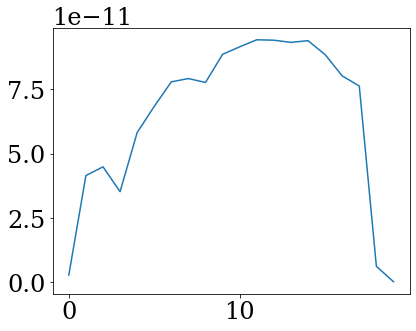

In [184]:
plt.plot(filter_integrate(wavels, vects_adj[:,0]*bandpass/np.max(bandpass), nwavels_binned, norm=False)[1])

In [175]:
filter_integrate(wavels, vects_adj[:,0], nwavels_binned, norm=False)

(Array([7.81686831e-07, 8.17061901e-07, 8.52436972e-07, 8.87812042e-07,
        9.23187113e-07, 9.58562183e-07, 9.93937254e-07, 1.02931232e-06,
        1.06468739e-06, 1.10006246e-06, 1.13543754e-06, 1.17081261e-06,
        1.20618768e-06, 1.24156275e-06, 1.27693782e-06, 1.31231289e-06,
        1.34768796e-06, 1.38306303e-06, 1.41843810e-06, 1.45381317e-06],      dtype=float64),
 Array([1.06150949e-10, 1.07165135e-10, 1.07144407e-10, 1.06827036e-10,
        1.07151191e-10, 1.07148744e-10, 1.07093240e-10, 1.06885824e-10,
        1.06635001e-10, 1.06427623e-10, 1.06152949e-10, 1.05849826e-10,
        1.05534228e-10, 1.05234073e-10, 1.04909008e-10, 1.04623048e-10,
        1.04405938e-10, 1.04085276e-10, 1.05880332e-10, 1.06059299e-10],      dtype=float64))

In [176]:
vects_binned = np.zeros((nwavels_binned,nvects))
vects_binned_upsampled = np.zeros((nwavels_binned*upsample,nvects))
vects_filt_binned = np.zeros((nwavels_binned,nvects))


for i in range(nvects):
    wavels_binned, vect_binned = filter_integrate(wavels, vects_adj[:,i], nwavels_binned, norm=False)
    wavels_binned_upsampled, vect_binned_upsampled = filter_integrate(wavels, vects_adj[:,i], nwavels_binned*upsample, norm=False)
    _, vect_filt_binned = filter_integrate(wavels, vects_adj[:,i]*bandpass, nwavels_binned, norm=False)
    #_, vect_filt_binned = filter_integrate(wavels, vects_adj[:,i], nwavels_binned, norm=False)
    vects_binned = vects_binned.at[:,i].set(vect_binned)
    vects_filt_binned = vects_filt_binned.at[:,i].set(vect_filt_binned)
    vects_binned_upsampled = vects_binned_upsampled.at[:,i].set(vect_binned_upsampled)

In [177]:
vects_binned = vects_binned/np.sqrt(np.mean(vects_binned**2, axis=0))
vects_filt_binned = vects_filt_binned/np.sqrt(np.mean(vects_filt_binned**2, axis=0))
vects_binned_upsampled = vects_binned_upsampled/np.sqrt(np.mean(vects_binned_upsampled**2, axis=0))

In [178]:
nv = 20
msk = np.arange(nv)#np.concat((np.arange(nv-1), np.array([-1])))

In [179]:
vects_binned = vects_binned[:,msk]
vects_filt_binned = vects_filt_binned[:,msk]
vects_binned_upsampled = vects_binned_upsampled[:,msk]

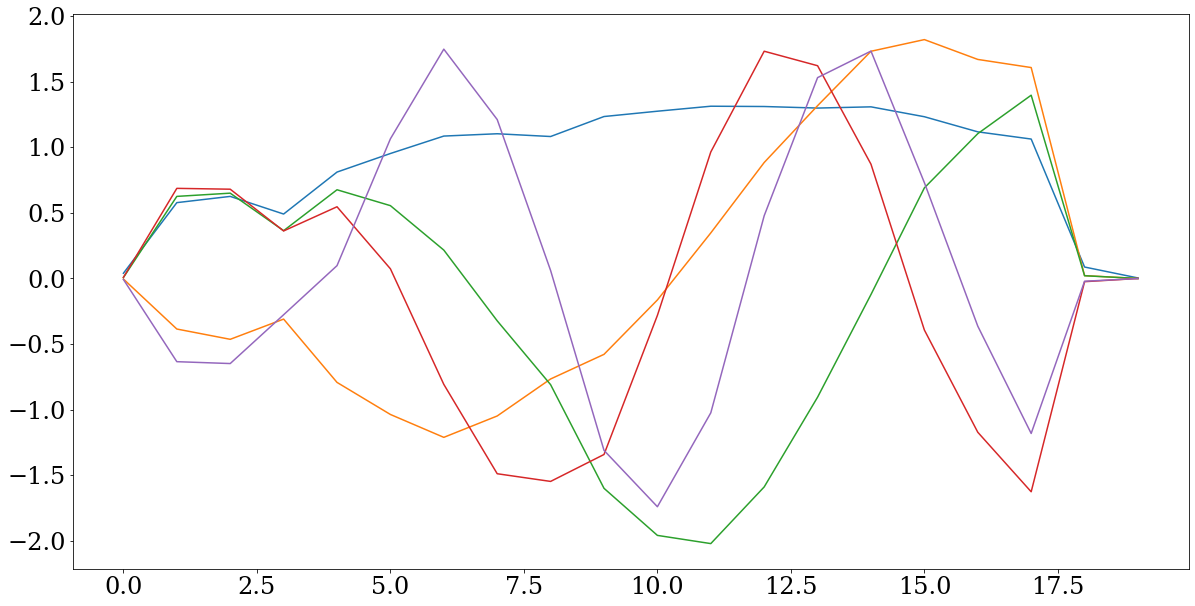

In [180]:
plt.figure(figsize=(20,10))



for i in range(5):
    plt.plot(np.real(vects_filt_binned[:,i]))

In [181]:
#stop

In [182]:
numpy.savez(f"../data/iterative_basis_binned.npz", 
    wavels_binned=wavels_binned,
    wavels_binned_upsampled=wavels_binned_upsampled,
    vects_binned=vects_binned,
    vects_filt_binned=vects_filt_binned,
    vects_binned_upsampled=vects_binned_upsampled,
)